# Notebook 08: Interpretation & Biomarkers

**Objetivo:** Conectar los resultados de ML (SHAP) con la base de datos de metabolitos para identificar biomarkers de interes biologico.

Etapas:
1. SHAP analysis profundo (beeswarm, waterfall, dependencia)
2. Ranking integrado: SHAP + Fold-Change + p-value
3. Conexion con BD de metabolitos (condiciones, evidencia)
4. Tabla final de biomarkers prioritarios
5. Resumen del proyecto completo

## 1. Imports y carga de datos

In [20]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import joblib
import shap

DATA_PROC = Path('../data/processed')
FIGURES   = Path('../figures')
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Load data ---
matches_df   = pd.read_csv(DATA_PROC / 'matches_enriched.csv')
shap_df      = pd.read_csv(DATA_PROC / '07_shap_importance.csv')
shap_no_df   = pd.read_csv(DATA_PROC / '07_shap_importance_no_outlier.csv')
fc_df        = pd.read_csv(DATA_PROC / '06_foldchange_ranking.csv')
fc_no_df     = pd.read_csv(DATA_PROC / '06_foldchange_ranking_no_outlier.csv')
hyp_df       = pd.read_csv(DATA_PROC / '06_hypothesis_testing_results.csv')
hyp_no_df    = pd.read_csv(DATA_PROC / '06_hypothesis_testing_results_no_outlier.csv')

rf_model    = joblib.load(DATA_PROC / '07_rf_model.pkl')
rf_model_no = joblib.load(DATA_PROC / '07_rf_model_no_outlier.pkl')

# --- Rebuild ML matrices (same as notebook 07) ---
exp_cols = [c for c in matches_df.columns if c.startswith('Exp_')]
X_raw = matches_df[exp_cols].values.T          # (17, 279)
metabolite_names = matches_df['compound_name'].values

clusters_df = pd.read_csv(DATA_PROC / 'experiment_clusters.csv')
clusters_df = clusters_df.sort_values('experiment').reset_index(drop=True)
y = clusters_df['cluster'].values
exp_labels = clusters_df['experiment'].values

X_ml = pd.DataFrame(X_raw, columns=metabolite_names, index=exp_labels)

print('Matrices cargadas:')
print(f'  X_ml: {X_ml.shape}  (experimentos x metabolitos)')
print(f'  y: {y.shape}  clases={np.unique(y, return_counts=True)}')
print(f'  matches_enriched: {matches_df.shape}')
print(f'  shap_importance: {shap_df.shape}')
print(f'  foldchange_ranking: {fc_df.shape}')
print(f'  hypothesis_testing: {hyp_df.shape}')


Matrices cargadas:
  X_ml: (17, 1230)  (experimentos x metabolitos)
  y: (17,)  clases=(array([0, 1]), array([16,  1]))
  matches_enriched: (1230, 35)
  shap_importance: (279, 2)
  foldchange_ranking: (279, 6)
  hypothesis_testing: (279, 5)


## 2. SHAP Analysis Profundo (analisis original con todos los experimentos)

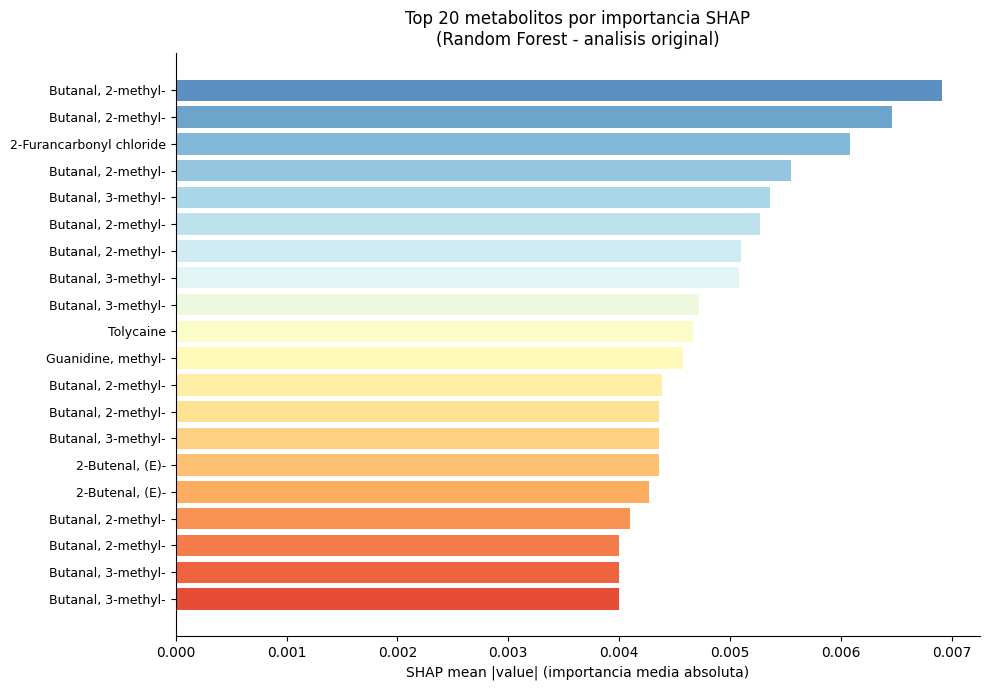

Guardado: 08_shap_beeswarm_original.png


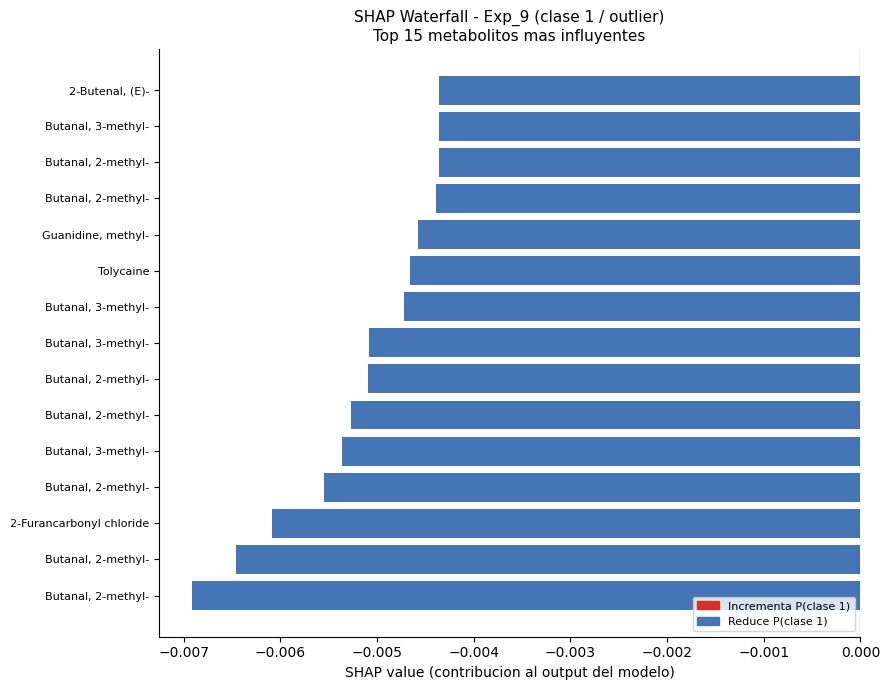

Guardado: 08_shap_waterfall_outlier.png  (exp: Exp_9)


In [21]:
# Recalcular SHAP values sobre el modelo RF entrenado con todos los datos
rf_full = rf_model  # ya entrenado en nb07
explainer = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(X_ml)

# shap_values puede ser lista (una matriz por clase) o array 3D
if isinstance(shap_values, list):
    shap_arr = np.array(shap_values)  # (n_classes, n_samples, n_features)
else:
    shap_arr = shap_values  # (n_samples, n_features, n_classes)
    shap_arr = np.transpose(shap_arr, (2, 0, 1))

# Importancia media absoluta por clase
shap_mean_per_class = np.abs(shap_arr).mean(axis=1)  # (n_classes, n_features)
shap_mean_all       = shap_mean_per_class.mean(axis=0)  # (n_features,)

top_n = 20  # reducido de 30 a 20 para mejorar legibilidad
top_idx = np.argsort(shap_mean_all)[::-1][:top_n]
top_names = [metabolite_names[i] for i in top_idx]
top_shap  = shap_mean_all[top_idx]

# --- Beeswarm-style: bar de importancia SHAP ---
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, top_n))
bars = ax.barh(range(top_n-1, -1, -1), top_shap, color=colors, edgecolor='none')
ax.set_yticks(range(top_n-1, -1, -1))
ax.set_yticklabels(top_names, fontsize=9)
ax.set_xlabel('SHAP mean |value| (importancia media absoluta)', fontsize=10)
ax.set_title(f'Top {top_n} metabolitos por importancia SHAP\n(Random Forest - analisis original)', fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / '08_shap_beeswarm_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: 08_shap_beeswarm_original.png')

# --- SHAP waterfall para el experimento con mayor diferencia (Exp_9 = clase 1) ---
minority_idx = np.where(y == 1)[0]
if len(minority_idx) > 0:
    exp_of_interest = minority_idx[0]
    exp_name = exp_labels[exp_of_interest]
    sv_c1 = shap_arr[1, exp_of_interest, :]  # (n_features,)
    base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

    top_wf_idx = np.argsort(np.abs(sv_c1))[::-1][:15]
    wf_names = [metabolite_names[i] for i in top_wf_idx]
    wf_vals  = sv_c1[top_wf_idx]

    fig, ax = plt.subplots(figsize=(9, 7))
    colors_wf = ['#d73027' if v > 0 else '#4575b4' for v in wf_vals]
    ax.barh(range(len(wf_vals)-1, -1, -1), wf_vals[::-1], color=colors_wf[::-1], edgecolor='none')
    ax.set_yticks(range(len(wf_vals)-1, -1, -1))
    ax.set_yticklabels(wf_names[::-1], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value (contribucion al output del modelo)', fontsize=10)
    ax.set_title(f'SHAP Waterfall - {exp_name} (clase 1 / outlier)\nTop 15 metabolitos mas influyentes', fontsize=11)
    red_p = mpatches.Patch(color='#d73027', label='Incrementa P(clase 1)')
    blue_p = mpatches.Patch(color='#4575b4', label='Reduce P(clase 1)')
    ax.legend(handles=[red_p, blue_p], fontsize=8, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(FIGURES / '08_shap_waterfall_outlier.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: 08_shap_waterfall_outlier.png  (exp: {exp_name})')
else:
    print('No se encontro experimento de clase 1 para waterfall')


## 3. Ranking Integrado: SHAP + Fold-Change + p-value

In [22]:
# Construir ranking integrado para el analisis original (2 clusters)
# a) Rank SHAP (1=mas importante)
# b) Rank fold-change absoluto (1=mayor)
# c) Rank -log10(p_value) (1=mas significativo)
# d) Score combinado = media de los 3 ranks

# -- SHAP rank --
shap_rank_df = shap_df.copy()
shap_rank_df.columns = ['metabolite', 'shap_mean_abs']
shap_rank_df['shap_rank'] = shap_rank_df['shap_mean_abs'].rank(ascending=False)

# -- Fold-change rank (por abs log2fc) --
fc_rank_df = fc_df[['metabolite', 'log2fc', 'effect_size', 'p_value']].copy()
fc_rank_df['abs_log2fc'] = fc_df['log2fc'].abs()
fc_rank_df['fc_rank'] = fc_rank_df['abs_log2fc'].rank(ascending=False)

# -- p-value rank (dedup: tomar min p_value por metabolito) --
hyp_min = hyp_df.groupby('metabolite')['p_adjusted'].min().reset_index()
hyp_min['neg_log10_p'] = -np.log10(np.clip(hyp_min['p_adjusted'].values, 1e-10, 1))
hyp_min['pval_rank'] = hyp_min['neg_log10_p'].rank(ascending=False)

# -- Merge todos --
ranking = shap_rank_df.merge(fc_rank_df, on='metabolite', how='outer')
ranking = ranking.merge(hyp_min[['metabolite', 'p_adjusted', 'neg_log10_p', 'pval_rank']], on='metabolite', how='outer')

# Rellenar ranks faltantes con el valor maximo + 1
max_rank = max(ranking['shap_rank'].max(), ranking['fc_rank'].max(), ranking['pval_rank'].max()) + 1
ranking['shap_rank']  = ranking['shap_rank'].fillna(max_rank)
ranking['fc_rank']    = ranking['fc_rank'].fillna(max_rank)
ranking['pval_rank']  = ranking['pval_rank'].fillna(max_rank)

ranking['combined_score'] = (ranking['shap_rank'] + ranking['fc_rank'] + ranking['pval_rank']) / 3.0
ranking = ranking.sort_values('combined_score').reset_index(drop=True)
ranking['final_rank'] = ranking.index + 1

top30_ranking = ranking.head(30)

print('Top 30 metabolitos por ranking integrado (SHAP + FC + p-value):')
display_cols = ['final_rank', 'metabolite', 'shap_mean_abs', 'abs_log2fc', 'p_adjusted', 'combined_score']
print(top30_ranking[display_cols].to_string(index=False))

# Guardar ranking completo
ranking.to_csv(DATA_PROC / '08_integrated_ranking.csv', index=False)
print('\nGuardado: 08_integrated_ranking.csv')


Top 30 metabolitos por ranking integrado (SHAP + FC + p-value):
 final_rank                                                 metabolite  shap_mean_abs  abs_log2fc  p_adjusted  combined_score
          1                                                     Phenol       0.006287   10.627467    0.166617       22.166667
          2                                             cis-Calamenene       0.004968   10.085172    0.166617       24.166667
          3                                             cis-Calamenene       0.004968    9.538843    0.166617       24.500000
          4                                                γ-Muurolene       0.004638    7.545405    0.166617       28.833333
          5                                          Methyl salicylate       0.004319    6.979729    0.166617       31.500000
          6                                                 α-Cubebene       0.004000    7.531006    0.166617       32.166667
          7                                        Dim

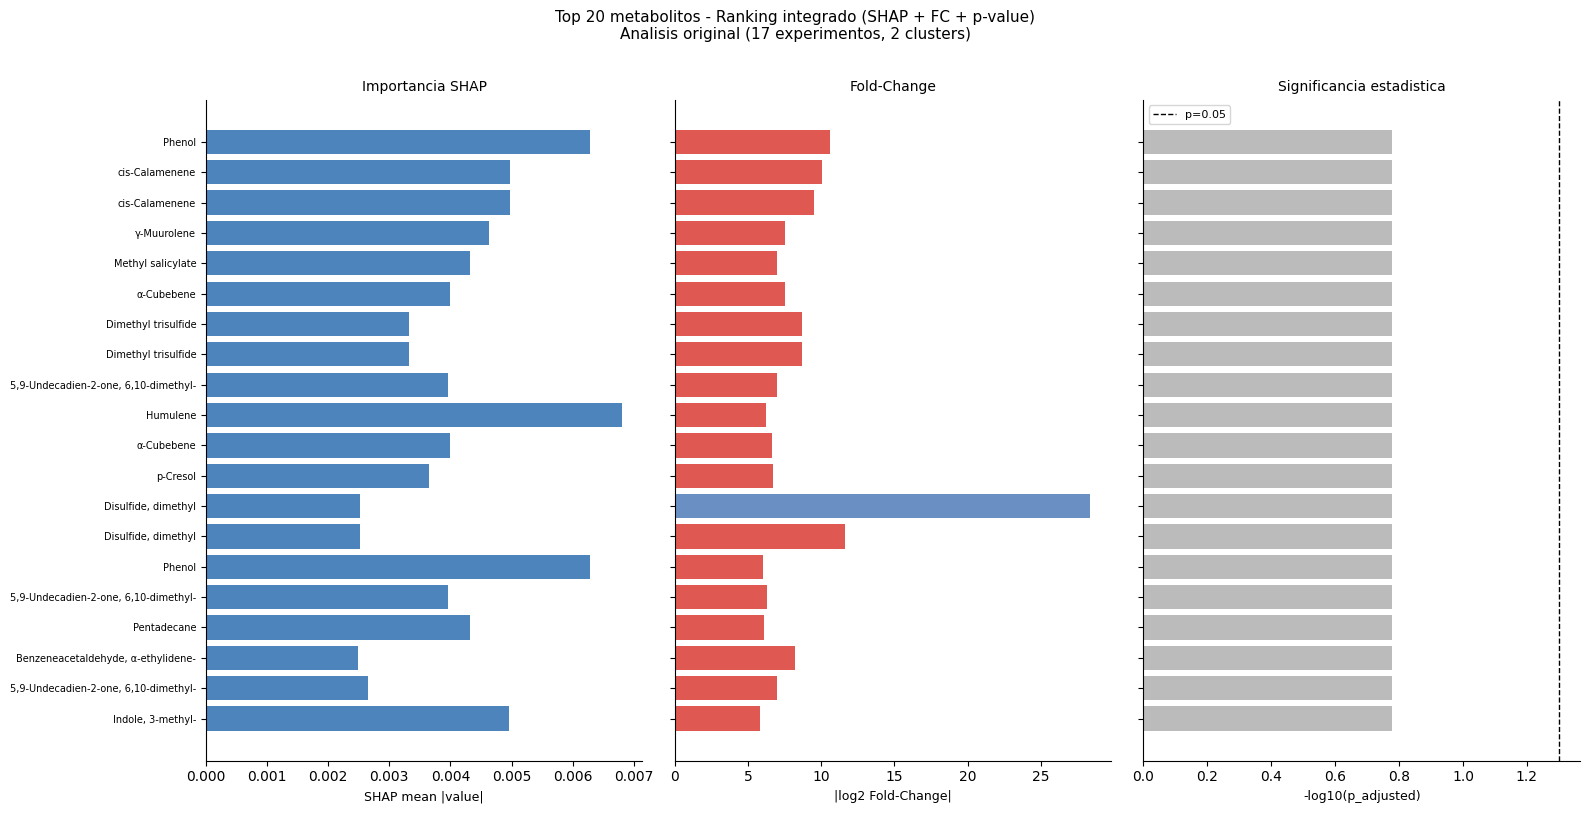

Guardado: 08_integrated_ranking_original.png


In [23]:
# Visualizacion del ranking integrado
top20 = top30_ranking.head(20)

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

# Panel 1: SHAP
ax = axes[0]
vals_shap = top20['shap_mean_abs'].fillna(0)
ax.barh(range(len(top20)-1, -1, -1), vals_shap, color='#2166ac', alpha=0.8)
ax.set_yticks(range(len(top20)-1, -1, -1))
ax.set_yticklabels(top20['metabolite'], fontsize=7)
ax.set_xlabel('SHAP mean |value|', fontsize=9)
ax.set_title('Importancia SHAP', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel 2: |log2FC|
ax = axes[1]
vals_fc = top20['abs_log2fc'].fillna(0)
colors_fc = ['#d73027' if fc >= 0 else '#4575b4' for fc in top20['log2fc'].fillna(0)]
ax.barh(range(len(top20)-1, -1, -1), vals_fc, color=colors_fc, alpha=0.8)
ax.set_yticks(range(len(top20)-1, -1, -1))
ax.set_yticklabels([], fontsize=7)
ax.set_xlabel('|log2 Fold-Change|', fontsize=9)
ax.set_title('Fold-Change', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel 3: -log10(p_adjusted)
ax = axes[2]
vals_p = top20['neg_log10_p'].fillna(0)
bar_colors = ['#d73027' if sig else '#aaaaaa' for sig in (top20['p_adjusted'].fillna(1) < 0.05)]
ax.barh(range(len(top20)-1, -1, -1), vals_p, color=bar_colors, alpha=0.8)
ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1, label='p=0.05')
ax.set_yticks(range(len(top20)-1, -1, -1))
ax.set_yticklabels([], fontsize=7)
ax.set_xlabel('-log10(p_adjusted)', fontsize=9)
ax.set_title('Significancia estadistica', fontsize=10)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Top 20 metabolitos - Ranking integrado (SHAP + FC + p-value)\nAnalisis original (17 experimentos, 2 clusters)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / '08_integrated_ranking_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: 08_integrated_ranking_original.png')


## 4. Conexion con la Base de Datos de Metabolitos

In [24]:
# Enriquecer el top ranking con informacion de la BD (matches_enriched)
# Columnas de interes: Condiciones, Evidencia, Origen_probable, Confianza_origen, Vinculo Microbio.

BD_COLS = ['compound_name', 'matched_biomarker', 'Condiciones', 'Evidencia',
           'Origen_probable', 'Confianza_origen', 'Vinculo Microbio.',
           'Volatilidad', 'Matriz', 'Flag_contaminante']

# Para cada compound_name, tomar el match de mayor score (o confianza)
matches_best = (
    matches_df[BD_COLS + ['match_score']]
    .sort_values('match_score', ascending=False)
    .drop_duplicates(subset='compound_name')
    .rename(columns={'compound_name': 'metabolite'})
)

# Merge con el top30 ranking
top30_enriched = top30_ranking.merge(matches_best, on='metabolite', how='left')

# Columnas finales para mostrar
show_cols = ['final_rank', 'metabolite', 'shap_mean_abs', 'abs_log2fc',
             'p_adjusted', 'combined_score', 'matched_biomarker',
             'Condiciones', 'Evidencia', 'Origen_probable', 'Confianza_origen',
             'Flag_contaminante']

top30_enriched_show = top30_enriched[show_cols].copy()
top30_enriched_show['shap_mean_abs'] = top30_enriched_show['shap_mean_abs'].round(5)
top30_enriched_show['abs_log2fc']    = top30_enriched_show['abs_log2fc'].round(2)
top30_enriched_show['p_adjusted']    = top30_enriched_show['p_adjusted'].round(4)
top30_enriched_show['combined_score']= top30_enriched_show['combined_score'].round(1)

print('Top 30 metabolitos enriquecidos con informacion de BD:')
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
print(top30_enriched_show.to_string(index=False))

# Guardar
top30_enriched.to_csv(DATA_PROC / '08_biomarker_candidates.csv', index=False)
print('\nGuardado: 08_biomarker_candidates.csv')

Top 30 metabolitos enriquecidos con informacion de BD:
 final_rank                                                 metabolite  shap_mean_abs  abs_log2fc  p_adjusted  combined_score   matched_biomarker                     Condiciones                              Evidencia      Origen_probable Confianza_origen    Flag_contaminante
          1                                                     Phenol        0.00629       10.63      0.1666            22.2              Phenol TDAHAnsied.AutismDepres.Esquiz. dataset_metabolomics text_mining_claim Biológico microbiano             Alta                   No
          2                                             cis-Calamenene        0.00497       10.09      0.1666            24.2                 NaN                         Depres.                   dataset_metabolomics          Desconocido             Baja                   No
          3                                             cis-Calamenene        0.00497        9.54      0.1666        

## 5. Tabla y Visualizacion de Biomarkers Prioritarios

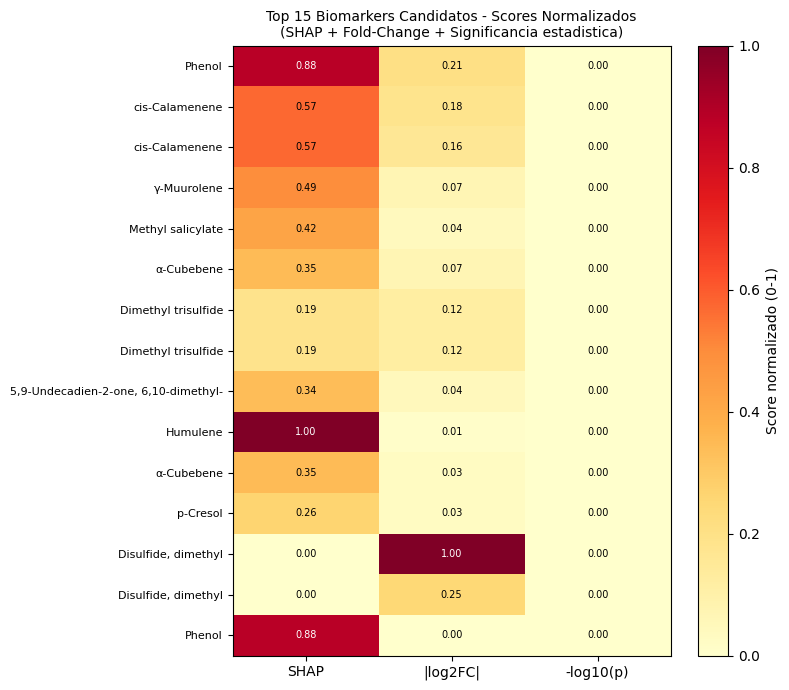

Guardado: 08_biomarker_heatmap_original.png

Biomarkers prioritarios (sin contaminantes): 30 de 30
 final_rank                           metabolite                     Condiciones Confianza_origen
          1                               Phenol TDAHAnsied.AutismDepres.Esquiz.             Alta
          2                       cis-Calamenene                         Depres.             Baja
          3                       cis-Calamenene                         Depres.             Baja
          4                          γ-Muurolene                         Depres.             Baja
          5                    Methyl salicylate                  Depres.Esquiz.             Baja
          6                           α-Cubebene                         Depres.             Baja
          7                  Dimethyl trisulfide                         Esquiz.             Baja
          8                  Dimethyl trisulfide                         Esquiz.             Baja
          9 5,9-Und

In [25]:
# Filtrar candidatos de alta prioridad:
# - No son contaminantes (Flag_contaminante != True)
# - Tienen origen probable o evidencia conocida
# - Top 20 por ranking combinado

candidates = top30_enriched.copy()

if 'Flag_contaminante' in candidates.columns:
    not_contaminant = ~candidates['Flag_contaminante'].astype(str).isin(['True', 'true', '1', 'yes'])
    candidates_clean = candidates[not_contaminant].copy()
else:
    candidates_clean = candidates.copy()

priority_cols = ['final_rank', 'metabolite', 'shap_mean_abs', 'log2fc',
                 'p_adjusted', 'Condiciones', 'Evidencia', 'Origen_probable', 'Confianza_origen']

priority_top15 = candidates_clean[priority_cols].head(15).copy()

# Heatmap de scores normalizados para los top 15
plot_data = priority_top15.set_index('metabolite')[['shap_mean_abs', 'log2fc', 'p_adjusted']].copy()
plot_data['abs_log2fc'] = plot_data['log2fc'].abs()
plot_data['neg_log10_p'] = -np.log10(np.clip(plot_data['p_adjusted'].values, 1e-10, 1))
plot_data = plot_data[['shap_mean_abs', 'abs_log2fc', 'neg_log10_p']]

plot_norm = plot_data.copy()
for col in plot_norm.columns:
    col_range = plot_norm[col].max() - plot_norm[col].min()
    if col_range > 0:
        plot_norm[col] = (plot_norm[col] - plot_norm[col].min()) / col_range
    else:
        plot_norm[col] = 0

plot_norm.columns = ['SHAP', '|log2FC|', '-log10(p)']

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(plot_norm.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(3))
ax.set_xticklabels(plot_norm.columns, fontsize=10)
ax.set_yticks(range(len(plot_norm)))
ax.set_yticklabels(plot_norm.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Score normalizado (0-1)')
ax.set_title('Top 15 Biomarkers Candidatos - Scores Normalizados\n(SHAP + Fold-Change + Significancia estadistica)', fontsize=10)

for i in range(len(plot_norm)):
    for j in range(3):
        v = plot_norm.values[i, j]
        text_color = 'white' if v > 0.6 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=text_color)

plt.tight_layout()
plt.savefig(FIGURES / '08_biomarker_heatmap_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: 08_biomarker_heatmap_original.png')

print(f'\nBiomarkers prioritarios (sin contaminantes): {len(candidates_clean)} de {len(candidates)}')
print(priority_top15[['final_rank', 'metabolite', 'Condiciones', 'Confianza_origen']].to_string(index=False))


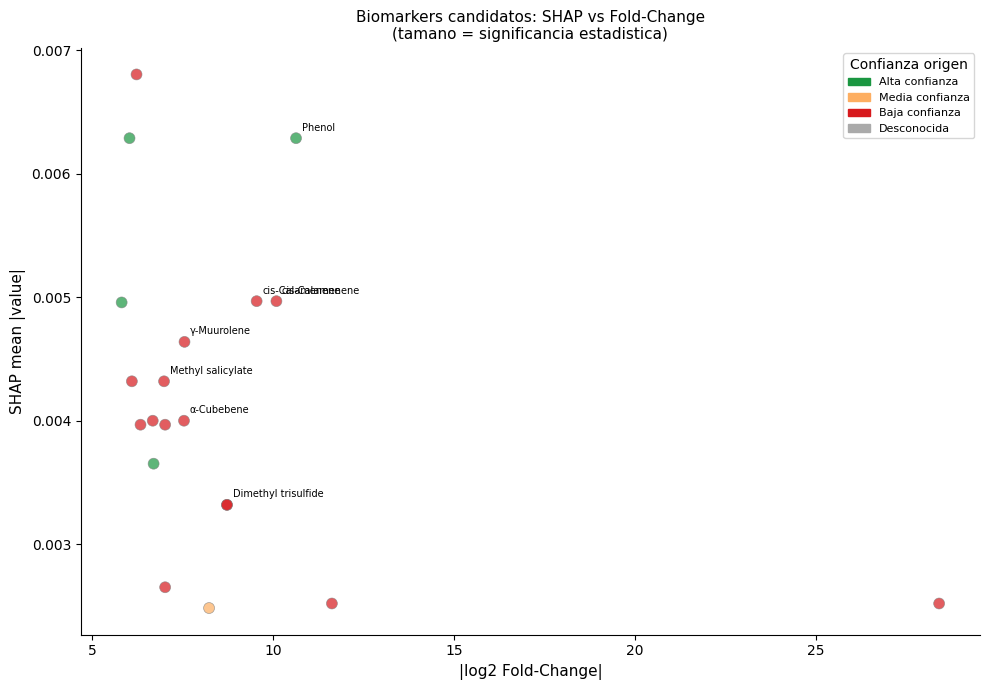

Guardado: 08_biomarker_bubble_original.png


In [26]:
# Bubble plot: SHAP vs |log2FC|, tamano = -log10(p), color = Confianza_origen
plot_b = candidates_clean.head(20).copy()
plot_b['abs_log2fc'] = plot_b['log2fc'].abs().fillna(0)
plot_b['neg_log10_p'] = -np.log10(np.clip(plot_b['p_adjusted'].fillna(1).values, 1e-10, 1))
plot_b['shap_mean_abs'] = plot_b['shap_mean_abs'].fillna(0)

conf_map = {'Alta': '#1a9641', 'Media': '#fdae61', 'Baja': '#d7191c',
            'Muy baja': '#d7191c', 'Desconocida': '#aaaaaa', float('nan'): '#aaaaaa'}
point_colors = [conf_map.get(str(c), '#aaaaaa') for c in plot_b['Confianza_origen']]

sizes = np.clip(plot_b['neg_log10_p'].values * 80, 30, 500)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(plot_b['abs_log2fc'], plot_b['shap_mean_abs'],
                s=sizes, c=point_colors, alpha=0.7, edgecolors='gray', linewidths=0.5)

# Etiquetar solo los top 7 para evitar solapamiento
texts_b = []
for _, row in plot_b.head(7).iterrows():
    t = ax.annotate(row['metabolite'][:25], (row['abs_log2fc'], row['shap_mean_abs']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')
    texts_b.append(t)

# Separar etiquetas automaticamente si adjustText esta disponible
try:
    from adjustText import adjust_text
    adjust_text(texts_b, ax=ax,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                expand_points=(1.4, 1.4), force_text=(0.5, 0.8))
except ImportError:
    pass  # adjustText no instalado; etiquetas con offset fijo

legend_items = [
    mpatches.Patch(color='#1a9641', label='Alta confianza'),
    mpatches.Patch(color='#fdae61', label='Media confianza'),
    mpatches.Patch(color='#d7191c', label='Baja confianza'),
    mpatches.Patch(color='#aaaaaa', label='Desconocida'),
]
ax.legend(handles=legend_items, title='Confianza origen', fontsize=8, loc='upper right')

ax.set_xlabel('|log2 Fold-Change|', fontsize=11)
ax.set_ylabel('SHAP mean |value|', fontsize=11)
ax.set_title('Biomarkers candidatos: SHAP vs Fold-Change\n(tamano = significancia estadistica)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / '08_biomarker_bubble_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: 08_biomarker_bubble_original.png')


## 6. Analisis Refinado (sin Exp_9 y Exp_11, 3 clusters)

In [27]:
# Cargar datos del analisis refinado
clusters_no_df = pd.read_csv(DATA_PROC / 'experiment_clusters_no_outlier.csv')
clusters_no_df = clusters_no_df.sort_values('experiment').reset_index(drop=True)

# Experimentos incluidos (excluyendo Exp_9 y Exp_11)
exp_included = clusters_no_df['experiment'].values
exp_idx = [list(exp_labels).index(e) for e in exp_included if e in list(exp_labels)]

X_ml_no = X_ml.loc[exp_included] if all(e in X_ml.index for e in exp_included) else X_ml.iloc[exp_idx]
y_no = clusters_no_df['cluster'].values

print(f'Analisis refinado: {X_ml_no.shape[0]} experimentos, {len(np.unique(y_no))} clusters')
print(f'Distribucion: {dict(zip(*np.unique(y_no, return_counts=True)))}')

# SHAP con modelo refinado
explainer_no = shap.TreeExplainer(rf_model_no)
shap_values_no = explainer_no.shap_values(X_ml_no)

if isinstance(shap_values_no, list):
    shap_arr_no = np.array(shap_values_no)
else:
    shap_arr_no = np.transpose(shap_values_no, (2, 0, 1))

shap_mean_no = np.abs(shap_arr_no).mean(axis=1).mean(axis=0)  # (n_features,)

top_idx_no = np.argsort(shap_mean_no)[::-1][:30]
top_names_no = [metabolite_names[i] for i in top_idx_no]
top_shap_no  = shap_mean_no[top_idx_no]

print(f'\nTop 10 SHAP (refinado):')
for n, v in zip(top_names_no[:10], top_shap_no[:10]):
    print(f'  {n}: {v:.5f}')

Analisis refinado: 15 experimentos, 3 clusters
Distribucion: {np.int64(0): np.int64(4), np.int64(1): np.int64(10), np.int64(2): np.int64(1)}

Top 10 SHAP (refinado):
  Propane, 2-methoxy-2-methyl-: 0.00662
  Butanal, 2-methyl-: 0.00622
  Butanal, 3-methyl-: 0.00596
  Butanal, 3-methyl-: 0.00577
  Butanal, 2-methyl-: 0.00560
  Butanal, 2-methyl-: 0.00529
  Butanal, 2-methyl-: 0.00526
  Butanal, 2-methyl-: 0.00512
  Butanal, 3-methyl-: 0.00510
  2-Propenal: 0.00488


In [28]:
# Ranking integrado para el analisis refinado
shap_no_rank_df = shap_no_df.copy()
shap_no_rank_df.columns = ['metabolite', 'shap_mean_abs']
shap_no_rank_df['shap_rank'] = shap_no_rank_df['shap_mean_abs'].rank(ascending=False)

fc_no_rank_df = fc_no_df[['metabolite', 'log2fc', 'effect_size', 'p_value']].copy()
fc_no_rank_df['abs_log2fc'] = fc_no_df['log2fc'].abs()
fc_no_rank_df['fc_rank'] = fc_no_rank_df['abs_log2fc'].rank(ascending=False)

hyp_no_min = hyp_no_df.groupby('metabolite')['p_adjusted'].min().reset_index()
hyp_no_min['neg_log10_p'] = -np.log10(np.clip(hyp_no_min['p_adjusted'].values, 1e-10, 1))
hyp_no_min['pval_rank'] = hyp_no_min['neg_log10_p'].rank(ascending=False)

ranking_no = shap_no_rank_df.merge(fc_no_rank_df, on='metabolite', how='outer')
ranking_no = ranking_no.merge(hyp_no_min[['metabolite', 'p_adjusted', 'neg_log10_p', 'pval_rank']], on='metabolite', how='outer')

max_rank_no = max(ranking_no['shap_rank'].max(), ranking_no['fc_rank'].max(), ranking_no['pval_rank'].max()) + 1
ranking_no['shap_rank']  = ranking_no['shap_rank'].fillna(max_rank_no)
ranking_no['fc_rank']    = ranking_no['fc_rank'].fillna(max_rank_no)
ranking_no['pval_rank']  = ranking_no['pval_rank'].fillna(max_rank_no)

ranking_no['combined_score'] = (ranking_no['shap_rank'] + ranking_no['fc_rank'] + ranking_no['pval_rank']) / 3.0
ranking_no = ranking_no.sort_values('combined_score').reset_index(drop=True)
ranking_no['final_rank'] = ranking_no.index + 1

top30_no = ranking_no.head(30)
top30_no_enriched = top30_no.merge(matches_best, on='metabolite', how='left')
top30_no_enriched.to_csv(DATA_PROC / '08_biomarker_candidates_no_outlier.csv', index=False)
ranking_no.to_csv(DATA_PROC / '08_integrated_ranking_no_outlier.csv', index=False)

print('Top 20 metabolitos - Analisis refinado (sin Exp_9 y Exp_11):')
print(top30_no[['final_rank', 'metabolite', 'shap_mean_abs', 'abs_log2fc', 'p_adjusted', 'combined_score']].head(20).to_string(index=False))
print('\nGuardado: 08_biomarker_candidates_no_outlier.csv')
print('Guardado: 08_integrated_ranking_no_outlier.csv')


Top 20 metabolitos - Analisis refinado (sin Exp_9 y Exp_11):
 final_rank                                           metabolite  shap_mean_abs  abs_log2fc  p_adjusted  combined_score
          1 Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate       0.005102    4.982335    0.035509       21.500000
          2 Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate       0.005102    4.709187    0.035509       22.166667
          3 Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate       0.004573    4.982335    0.035509       22.500000
          4 Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate       0.004573    4.709187    0.035509       23.166667
          5 Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate       0.005102    4.404984    0.035509       23.833333
          6 Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate       0.005102    4.355558    0.035509       24.166667
          7                                  Benzeneacetaldehyde       0.005650    3.684206    0.03

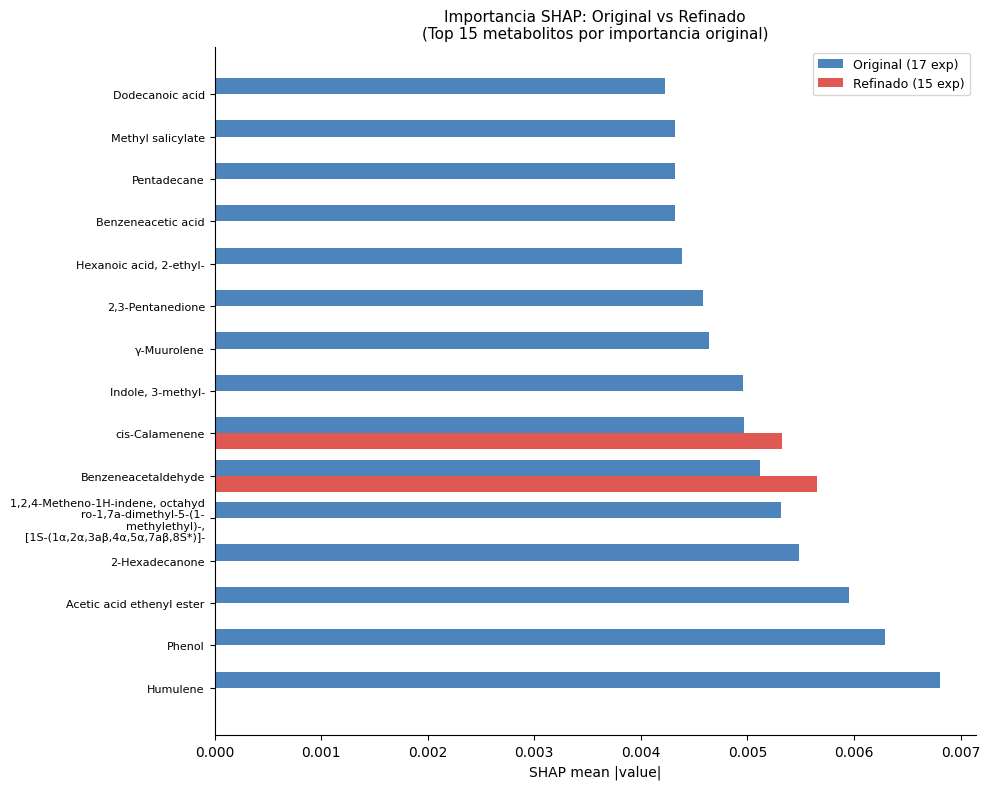

Guardado: 08_shap_comparison_orig_vs_refined.png

Metabolitos en comun (top 10 SHAP original vs refinado): 2
  Benzeneacetaldehyde
  cis-Calamenene


In [29]:
import textwrap as _tw

# Visualizacion: comparacion original vs refinado (top 15 metabolitos por SHAP)
top15_orig = shap_df.head(15).copy()
top15_orig.columns = ['metabolite', 'shap_orig']
top15_ref  = shap_no_df.head(15).copy()
top15_ref.columns  = ['metabolite', 'shap_ref']

compare = top15_orig.merge(top15_ref, on='metabolite', how='outer').fillna(0)
compare = compare.sort_values('shap_orig', ascending=False).head(15)

# Recortar nombres largos para el eje Y (max 32 caracteres)
compare['label'] = compare['metabolite'].apply(
    lambda n: _tw.fill(n, width=32) if len(n) > 32 else n)

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(compare))
width = 0.38
ax.barh(x + width/2, compare['shap_orig'], width, label='Original (17 exp)', color='#2166ac', alpha=0.8)
ax.barh(x - width/2, compare['shap_ref'],  width, label='Refinado (15 exp)', color='#d73027',  alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(compare['label'], fontsize=8)
ax.set_xlabel('SHAP mean |value|', fontsize=10)
ax.set_title('Importancia SHAP: Original vs Refinado\n(Top 15 metabolitos por importancia original)', fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / '08_shap_comparison_orig_vs_refined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: 08_shap_comparison_orig_vs_refined.png')

# Metabolitos en comun top10
top10_orig_set = set(shap_df.head(10)['metabolite'])
top10_ref_set  = set(shap_no_df.head(10)['metabolite'])
common = top10_orig_set & top10_ref_set
print(f'\nMetabolitos en comun (top 10 SHAP original vs refinado): {len(common)}')
for m in sorted(common):
    print(f'  {m}')


## 7. Resumen Final del Proyecto

In [30]:
from datetime import datetime

top5_biomarkers = top30_enriched.head(5)[['metabolite', 'Condiciones', 'Origen_probable', 'Confianza_origen']]
top5_biomarkers_no = top30_no_enriched.head(5)[['metabolite', 'Condiciones', 'Origen_probable', 'Confianza_origen']]

summary_lines = [
    '=' * 70,
    'RESUMEN EJECUTIVO DEL PROYECTO',
    'Analisis Metabolomico GC-MS - Identificacion de Biomarkers',
    f'Fecha: {datetime.now().strftime("%Y-%m-%d")}',
    '=' * 70,
    '',
    '1. DATOS DE ENTRADA',
    '   - Matriz original: 279 metabolitos x 17 experimentos',
    '   - Metodo: GC-MS',
    '   - Matching con base de datos: matches_enriched.csv',
    '',
    '2. CLUSTERING (Notebook 05)',
    '   Analisis original (17 exp):',
    '     - K=2: Cluster 0 (16 exp), Cluster 1 (Exp_9 - outlier)',
    '   Analisis refinado (15 exp, sin Exp_9 y Exp_11):',
    '     - K=3: Cluster 0 (Exp_1-4, n=4), Cluster 1 (n=10), Cluster 2 (Exp_8, n=1)',
    '',
    '3. HYPOTHESIS TESTING (Notebook 06)',
    '   - Test: Mann-Whitney U (2 grupos) / Kruskal-Wallis (3 grupos)',
    '   - Correccion FDR: Benjamini-Hochberg',
    '   - Nota: con n=1 en clase minoritaria, p_min = 0.118 (significancia imposible)',
    '   - Alternativa: ranking por fold-change',
    '',
    '4. ML PIPELINE (Notebook 07)',
    '   - Modelos: Random Forest + XGBoost',
    '   - CV: Leave-One-Out (LOO-CV, n=17)',
    '   - Manejo de desbalance: class_weight=balanced / scale_pos_weight',
    '   - Interpretacion: SHAP TreeExplainer',
    '',
    '5. TOP 5 BIOMARKERS CANDIDATOS (analisis original)',
]

for _, row in top5_biomarkers.iterrows():
    cond = str(row['Condiciones'])[:50] if pd.notna(row['Condiciones']) else 'N/A'
    orig = str(row['Origen_probable'])[:30] if pd.notna(row['Origen_probable']) else 'N/A'
    conf = str(row['Confianza_origen']) if pd.notna(row['Confianza_origen']) else 'N/A'
    summary_lines.append(f'   - {row["metabolite"][:40]}')
    summary_lines.append(f'     Condiciones: {cond}')
    summary_lines.append(f'     Origen: {orig} | Confianza: {conf}')

summary_lines += [
    '',
    '6. TOP 5 BIOMARKERS CANDIDATOS (analisis refinado, sin Exp_9/11)',
]

for _, row in top5_biomarkers_no.iterrows():
    cond = str(row['Condiciones'])[:50] if pd.notna(row['Condiciones']) else 'N/A'
    orig = str(row['Origen_probable'])[:30] if pd.notna(row['Origen_probable']) else 'N/A'
    conf = str(row['Confianza_origen']) if pd.notna(row['Confianza_origen']) else 'N/A'
    summary_lines.append(f'   - {row["metabolite"][:40]}')
    summary_lines.append(f'     Condiciones: {cond}')
    summary_lines.append(f'     Origen: {orig} | Confianza: {conf}')

summary_lines += [
    '',
    '7. ARCHIVOS GENERADOS',
    '   data/processed/',
    '     - 06_hypothesis_testing_results.csv / _no_outlier.csv',
    '     - 06_foldchange_ranking.csv / _no_outlier.csv',
    '     - 07_rf_model.pkl, 07_xgb_model.pkl (y variantes no_outlier)',
    '     - 07_shap_importance.csv / _no_outlier.csv',
    '     - 08_integrated_ranking.csv / _no_outlier.csv',
    '     - 08_biomarker_candidates.csv / _no_outlier.csv',
    '   figures/',
    '     - 08_shap_beeswarm_original.png',
    '     - 08_shap_waterfall_outlier.png',
    '     - 08_integrated_ranking_original.png',
    '     - 08_biomarker_heatmap_original.png',
    '     - 08_biomarker_bubble_original.png',
    '     - 08_shap_comparison_orig_vs_refined.png',
    '=' * 70,
]

summary_text = '\n'.join(summary_lines)
print(summary_text)

# Guardar
output_dir = Path('../')
with open(output_dir / 'PROJECT_SUMMARY.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)
print('\nGuardado: PROJECT_SUMMARY.txt')

RESUMEN EJECUTIVO DEL PROYECTO
Analisis Metabolomico GC-MS - Identificacion de Biomarkers
Fecha: 2026-03-09

1. DATOS DE ENTRADA
   - Matriz original: 279 metabolitos x 17 experimentos
   - Metodo: GC-MS
   - Matching con base de datos: matches_enriched.csv

2. CLUSTERING (Notebook 05)
   Analisis original (17 exp):
     - K=2: Cluster 0 (16 exp), Cluster 1 (Exp_9 - outlier)
   Analisis refinado (15 exp, sin Exp_9 y Exp_11):
     - K=3: Cluster 0 (Exp_1-4, n=4), Cluster 1 (n=10), Cluster 2 (Exp_8, n=1)

3. HYPOTHESIS TESTING (Notebook 06)
   - Test: Mann-Whitney U (2 grupos) / Kruskal-Wallis (3 grupos)
   - Correccion FDR: Benjamini-Hochberg
   - Nota: con n=1 en clase minoritaria, p_min = 0.118 (significancia imposible)
   - Alternativa: ranking por fold-change

4. ML PIPELINE (Notebook 07)
   - Modelos: Random Forest + XGBoost
   - CV: Leave-One-Out (LOO-CV, n=17)
   - Manejo de desbalance: class_weight=balanced / scale_pos_weight
   - Interpretacion: SHAP TreeExplainer

5. TOP 5 BIO

In [31]:
# Verificacion de archivos generados
all_outputs = [
    DATA_PROC / '08_integrated_ranking.csv',
    DATA_PROC / '08_biomarker_candidates.csv',
    DATA_PROC / '08_integrated_ranking_no_outlier.csv',
    DATA_PROC / '08_biomarker_candidates_no_outlier.csv',
    FIGURES / '08_shap_beeswarm_original.png',
    FIGURES / '08_shap_waterfall_outlier.png',
    FIGURES / '08_integrated_ranking_original.png',
    FIGURES / '08_biomarker_heatmap_original.png',
    FIGURES / '08_biomarker_bubble_original.png',
    FIGURES / '08_shap_comparison_orig_vs_refined.png',
    Path('../PROJECT_SUMMARY.txt'),
]

print('Verificacion de outputs del Notebook 08:')
all_ok = True
for p in all_outputs:
    exists = p.exists()
    status = 'OK' if exists else 'FALTA'
    size = f'{p.stat().st_size:,} bytes' if exists else ''
    print(f'  [{status}] {p.name}  {size}')
    if not exists:
        all_ok = False

if all_ok:
    print('\nNotebook 08 completado correctamente.')
else:
    print('\nAlgunos archivos no se generaron correctamente.')

Verificacion de outputs del Notebook 08:
  [OK] 08_integrated_ranking.csv  170,947 bytes
  [OK] 08_biomarker_candidates.csv  9,594 bytes
  [OK] 08_integrated_ranking_no_outlier.csv  167,295 bytes
  [OK] 08_biomarker_candidates_no_outlier.csv  10,204 bytes
  [OK] 08_shap_beeswarm_original.png  82,925 bytes
  [OK] 08_shap_waterfall_outlier.png  72,557 bytes
  [OK] 08_integrated_ranking_original.png  108,125 bytes
  [OK] 08_biomarker_heatmap_original.png  101,826 bytes
  [OK] 08_biomarker_bubble_original.png  72,230 bytes
  [OK] 08_shap_comparison_orig_vs_refined.png  80,636 bytes
  [OK] PROJECT_SUMMARY.txt  3,130 bytes

Notebook 08 completado correctamente.


---
# Análisis Mejorado: Interpretación Científica Rigurosa

Las siguientes secciones amplían el análisis anterior con mayor rigor científico.  
Todos los resultados existentes se conservan; las nuevas celdas añaden estructura,
deduplicación e interpretación más clara.


## 08A – Interpretación del Análisis Original

Este análisis utiliza los clusters obtenidos con **los 17 experimentos** (incluyendo Exp_9,
identificado como outlier en el Notebook 05).

> **Nota:** El clustering original está fuertemente influenciado por la presencia de outliers
> (Exp_9 forma su propio cluster). Los resultados deben interpretarse principalmente como **exploratorios**,
> ya que el desbalance de clases (16 vs. 1 experimento) hace que las pruebas estadísticas y el
> aprendizaje automático sean inherentemente inestables. Los metabolitos candidatos identificados aquí
> son ilustrativos de la señal introducida por esa muestra extrema única.


## 08B – Interpretación del Análisis Refinado (sin Exp_9 y Exp_11)

El análisis refinado excluye los dos experimentos más extremos (Exp_9 y Exp_11),
identificados como outliers en el Notebook 05.

- Permite estudiar mejor la **subestructura del grupo principal de muestras**
  (15 experimentos, 3 clusters con tamaños más equilibrados).
- La estructura de 3 clusters proporciona comparaciones estadísticas más fiables y
  atribuciones SHAP más estables.

> **El análisis refinado se utiliza para la interpretación principal de los metabolitos candidatos priorizados.**


## Criterios de Ranking Separados (con Deduplicación)

Para evitar que el mismo metabolito aparezca varias veces (por múltiples coincidencias
en la base de datos), los metabolitos se agrupan por nombre antes de ordenar.
Para cada metabolito único se conserva la **fila con mejor puntuación combinada**.

Los tres rankings independientes se presentan por separado:

| # | Criterio | Qué mide |
|---|----------|----------|
| 1 | **Importancia SHAP** | Importancia predictiva para el modelo |
| 2 | **\|log2 fold change\|** | Magnitud del cambio de abundancia entre clusters |
| 3 | **p-valor ajustado** | Evidencia estadística de diferencia entre grupos |


In [32]:
# ============================================================
# DEDUPLICACIÓN – conservar la mejor fila por nombre único de metabolito
# ============================================================

# Análisis refinado (principal)
ranking_no_dedup_u = (
    ranking_no
    .sort_values('combined_score')
    .drop_duplicates(subset='metabolite', keep='first')
    .reset_index(drop=True)
)

# Análisis original (exploratorio)
ranking_dedup_u = (
    ranking
    .sort_values('combined_score')
    .drop_duplicates(subset='metabolite', keep='first')
    .reset_index(drop=True)
)

print(f'Análisis refinado   – metabolitos únicos: {len(ranking_no_dedup_u):4d}  (de {len(ranking_no):4d} filas)')
print(f'Análisis original   – metabolitos únicos: {len(ranking_dedup_u):4d}  (de {len(ranking):4d} filas)')


Refined analysis  – unique metabolites:  143  (from 1055 rows)
Original analysis – unique metabolites:  143  (from 1055 rows)


### Tabla 1 – Metabolitos Candidatos por Importancia SHAP

Ordenados por **SHAP mean |value|** (mayor = más importante para la predicción del modelo).
Representa la **importancia predictiva**: cuánto contribuye cada metabolito a
distinguir los clusters en el modelo Random Forest.


In [33]:
# Tabla 1 – Importancia SHAP (análisis refinado, deduplicado)
t1 = (
    ranking_no_dedup_u
    .sort_values('shap_mean_abs', ascending=False)
    .head(15)[['metabolite', 'shap_mean_abs', 'abs_log2fc', 'p_adjusted']]
    .reset_index(drop=True)
)
t1.index += 1
t1.columns = ['Metabolito', 'Importancia SHAP', '|log2FC|', 'p_ajustado']
t1['Importancia SHAP'] = t1['Importancia SHAP'].round(5)
t1['|log2FC|']         = t1['|log2FC|'].round(3)
t1['p_ajustado']       = t1['p_ajustado'].round(4)

pd.set_option('display.max_colwidth', 50)
print('Tabla 1 – Top 15 metabolitos candidatos por importancia SHAP (refinado, deduplicado):')
print(t1.to_string())
t1.to_csv(DATA_PROC / '08_tabla1_shap_ranking_dedup.csv')
print('\nGuardado: 08_tabla1_shap_ranking_dedup.csv')


Table 1 – Top 15 candidate metabolites by SHAP importance (refined, deduplicated):
                                              Metabolite  SHAP importance  |log2FC|  p_adjusted
1                                             2-Nonanone          0.00712       NaN      0.0355
2                            Dodecane, 2,6,10-trimethyl-          0.00618       NaN      0.0355
3                                       Dimethyl sulfone          0.00613       NaN      0.0355
4                                               p-Cresol          0.00567     3.307      0.0355
5                                    Benzeneacetaldehyde          0.00565     3.684      0.0355
6                                    Phenylethyl Alcohol          0.00557       NaN      0.0355
7                                                 Indole          0.00543       NaN      0.0355
8                                        n-Decanoic acid          0.00543       NaN      0.0355
9                                         cis-Calamen

### Tabla 2 – Metabolitos Candidatos por Fold Change Absoluto

Ordenados por **|log2FC|** (mayor = mayor tamaño del efecto entre clusters).
Representa la **magnitud de la señal biológica**: metabolitos más diferentes en
abundancia entre los grupos de muestras, independientemente de la significancia
estadística o la importancia del modelo.


In [34]:
# Tabla 2 – |log2FC| (análisis refinado, deduplicado)
t2 = (
    ranking_no_dedup_u
    .sort_values('abs_log2fc', ascending=False)
    .head(15)[['metabolite', 'shap_mean_abs', 'abs_log2fc', 'p_adjusted']]
    .reset_index(drop=True)
)
t2.index += 1
t2.columns = ['Metabolito', 'Importancia SHAP', '|log2FC|', 'p_ajustado']
t2['Importancia SHAP'] = t2['Importancia SHAP'].round(5)
t2['|log2FC|']         = t2['|log2FC|'].round(3)
t2['p_ajustado']       = t2['p_ajustado'].round(4)

print('Tabla 2 – Top 15 metabolitos candidatos por |log2FC| (refinado, deduplicado):')
print(t2.to_string())
t2.to_csv(DATA_PROC / '08_tabla2_fc_ranking_dedup.csv')
print('\nGuardado: 08_tabla2_fc_ranking_dedup.csv')


Table 2 – Top 15 candidate metabolites by |log2FC| (refined, deduplicated):
                                              Metabolite  SHAP importance  |log2FC|  p_adjusted
1                                       2,3-Pentanedione          0.00162    14.230      0.1622
2    2-Butyl-3-(4-β-diethylaminoethoxybenzoyl)benzofuran          0.00043     8.429      0.2798
3                              Acetic acid ethenyl ester          0.00129     7.301      0.2798
4                                             D-Limonene          0.00429     7.050      0.0371
5              Benzenepropionic acid, 2-tetradecyl ester          0.00252     6.203      0.0376
6   Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate          0.00510     4.982      0.0355
7                                Hexanoic acid, 2-ethyl-          0.00247     4.817      0.0639
8                                                Hexanal          0.00059     4.708      0.2470
9                                            2-Pentanone    

### Tabla 3 – Metabolitos Candidatos por p-valor Ajustado

Ordenados por **p_adjusted** (menor = mayor evidencia estadística).
Representa la **evidencia estadística**: metabolitos cuyas diferencias entre
grupos son menos probables de explicarse por azar tras la corrección por comparaciones múltiples.

> **Nota:** Con n = 15 experimentos y 3 clusters, alcanzar p_adjusted < 0.05
> es difícil. Los metabolitos con p_adjusted < 0.10 se consideran potencialmente
> significativos bajo criterios relajados, justificados por el carácter exploratorio de este estudio.


In [35]:
# Tabla 3 – p-valor ajustado (análisis refinado, deduplicado)
t3 = (
    ranking_no_dedup_u
    .sort_values('p_adjusted', ascending=True)
    .head(15)[['metabolite', 'shap_mean_abs', 'abs_log2fc', 'p_adjusted']]
    .reset_index(drop=True)
)
t3.index += 1
t3.columns = ['Metabolito', 'Importancia SHAP', '|log2FC|', 'p_ajustado']
t3['Importancia SHAP'] = t3['Importancia SHAP'].round(5)
t3['|log2FC|']         = t3['|log2FC|'].round(3)
t3['p_ajustado']       = t3['p_ajustado'].round(4)

umbral_sig = 0.10
n_sig = (t3['p_ajustado'] < umbral_sig).sum()

print('Tabla 3 – Top 15 metabolitos candidatos por p-valor ajustado (refinado, deduplicado):')
print(t3.to_string())
print(f'\nMetabolitos con p_ajustado < {umbral_sig}: {n_sig}')
t3.to_csv(DATA_PROC / '08_tabla3_pval_ranking_dedup.csv')
print('Guardado: 08_tabla3_pval_ranking_dedup.csv')


Table 3 – Top 15 candidate metabolites by adjusted p-value (refined, deduplicated):
                                              Metabolite  SHAP importance  |log2FC|  p_adjusted
1   Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate          0.00510     4.982      0.0355
2                                    Benzeneacetaldehyde          0.00565     3.684      0.0355
3                                               p-Cresol          0.00567     3.307      0.0355
4                                     Butanal, 2-methyl-          0.00263     2.275      0.0355
5                                              Methional          0.00195     4.246      0.0355
6                                     Butanal, 3-methyl-          0.00171     3.738      0.0355
7                                    Propanal, 2-methyl-          0.00424       NaN      0.0355
8                                     Benzeneacetic acid          0.00404       NaN      0.0355
9                                         cis-Calame

## Metabolitos Candidatos Priorizados (Intersección de Criterios)

Los metabolitos que aparecen en el **top 20 de al menos dos de los tres criterios**
(importancia SHAP, |log2FC|, p-valor ajustado) en el análisis refinado se seleccionan
como **metabolitos candidatos priorizados**.

Este enfoque de intersección reduce el riesgo de seleccionar características que puntúan
alto en un único criterio (lo que podría reflejar ruido o artefactos específicos del modelo).

| Columna | Descripción |
|---------|-------------|
| `n_criteria` | Número de listas top-20 en las que aparece el metabolito (máx. 3) |
| `present_in_enriched_database` | Si el metabolito tiene coincidencia en la BD de referencia |
| `interpretation_notes` | Resumen de criterios cumplidos, condiciones asociadas y alertas |


In [36]:
# ============================================================
# METABOLITOS CANDIDATOS PRIORIZADOS – INTERSECCIÓN DE CRITERIOS
# ============================================================

TOP_N = 20

top_shap_set = set(ranking_no_dedup_u.sort_values('shap_mean_abs', ascending=False).head(TOP_N)['metabolite'])
top_fc_set   = set(ranking_no_dedup_u.sort_values('abs_log2fc',    ascending=False).head(TOP_N)['metabolite'])
top_pval_set = set(ranking_no_dedup_u.sort_values('p_adjusted',    ascending=True ).head(TOP_N)['metabolite'])

all_met = top_shap_set | top_fc_set | top_pval_set
prio_df = pd.DataFrame({'metabolite': sorted(all_met)})
prio_df['in_shap_top20'] = prio_df['metabolite'].isin(top_shap_set)
prio_df['in_fc_top20']   = prio_df['metabolite'].isin(top_fc_set)
prio_df['in_pval_top20'] = prio_df['metabolite'].isin(top_pval_set)
prio_df['n_criteria']    = prio_df[['in_shap_top20','in_fc_top20','in_pval_top20']].sum(axis=1)

# Unir métricas
prio_df = prio_df.merge(
    ranking_no_dedup_u[['metabolite','shap_mean_abs','abs_log2fc','p_adjusted']],
    on='metabolite', how='left'
)
# Unir información de la BD enriquecida
prio_df = prio_df.merge(
    matches_best[['metabolite','matched_biomarker','Condiciones','Origen_probable',
                  'Confianza_origen','Flag_contaminante']],
    on='metabolite', how='left'
)
prio_df['presente_en_bd'] = prio_df['matched_biomarker'].notna()

def generar_notas(row):
    criterios = [c for c, f in [('SHAP', row['in_shap_top20']),
                                  ('FC',   row['in_fc_top20']),
                                  ('p-val',row['in_pval_top20'])] if f]
    partes = [f"Top-20 en: {', '.join(criterios)}"]
    if pd.notna(row.get('Condiciones')):
        partes.append(f"Asoc: {str(row['Condiciones'])[:45]}")
    if pd.notna(row.get('Confianza_origen')):
        partes.append(f"Conf: {row['Confianza_origen']}")
    if str(row.get('Flag_contaminante','No')) in ['True','true','1','yes','Posible_contaminante']:
        partes.append('POSIBLE CONTAMINANTE')
    return ' | '.join(partes)

prio_df['notas_interpretacion'] = prio_df.apply(generar_notas, axis=1)

prio_final = (
    prio_df[prio_df['n_criteria'] >= 2]
    .sort_values(['n_criteria','shap_mean_abs'], ascending=[False,False])
    .reset_index(drop=True)
)
prio_final.index += 1

mostrar = ['metabolite','shap_mean_abs','abs_log2fc','p_adjusted',
           'presente_en_bd','notas_interpretacion']

print(f'Metabolitos candidatos priorizados (refinado, >=2 criterios, top-{TOP_N} cada uno):')
print(f'Total: {len(prio_final)}')
print()
pd.set_option('display.max_colwidth', 65)
print(prio_final[mostrar].to_string())

prio_final.to_csv(DATA_PROC / '08_candidatos_priorizados.csv', index=False)
print('\nGuardado: 08_candidatos_priorizados.csv')


Prioritized candidate metabolites (refined, >=2 criteria, top-20 each):
Total: 18

                                              metabolite  shap_mean_abs  abs_log2fc  p_adjusted  present_in_enriched_database                                                              interpretation_notes
1                                               p-Cresol       0.005672    3.307008    0.035509                          True      Top-20 in: SHAP, FC, p-val | Assoc: AutismBipolarDepres.Esquiz. | Conf: Alta
2                                    Benzeneacetaldehyde       0.005650    3.684206    0.035509                          True  Top-20 in: SHAP, FC, p-val | Assoc: Esquiz. | Conf: Media | POSSIBLE CONTAMINANT
3   Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate       0.005102    4.982335    0.035509                          True                          Top-20 in: SHAP, FC, p-val | Assoc: Esquiz. | Conf: Alta
4                                             2-Nonanone       0.007115         NaN  

## Heatmap Mejorado: Abundancias Z-score de los Metabolitos Candidatos Priorizados

A diferencia del heatmap de puntuaciones normalizadas anterior (que muestra
*puntuaciones de ranking relativas*), este heatmap muestra las
**abundancias escaladas en z-score reales** de los principales metabolitos candidatos
priorizados a lo largo de todos los experimentos del análisis refinado.

**Título del heatmap anterior:** *Puntuaciones de priorización normalizadas
(SHAP, tamaño de efecto y evidencia estadística)*  
Este nuevo gráfico refleja **patrones de abundancia relativa reales**, permitiendo
identificar qué experimentos y clusters explican la señal de cada candidato.


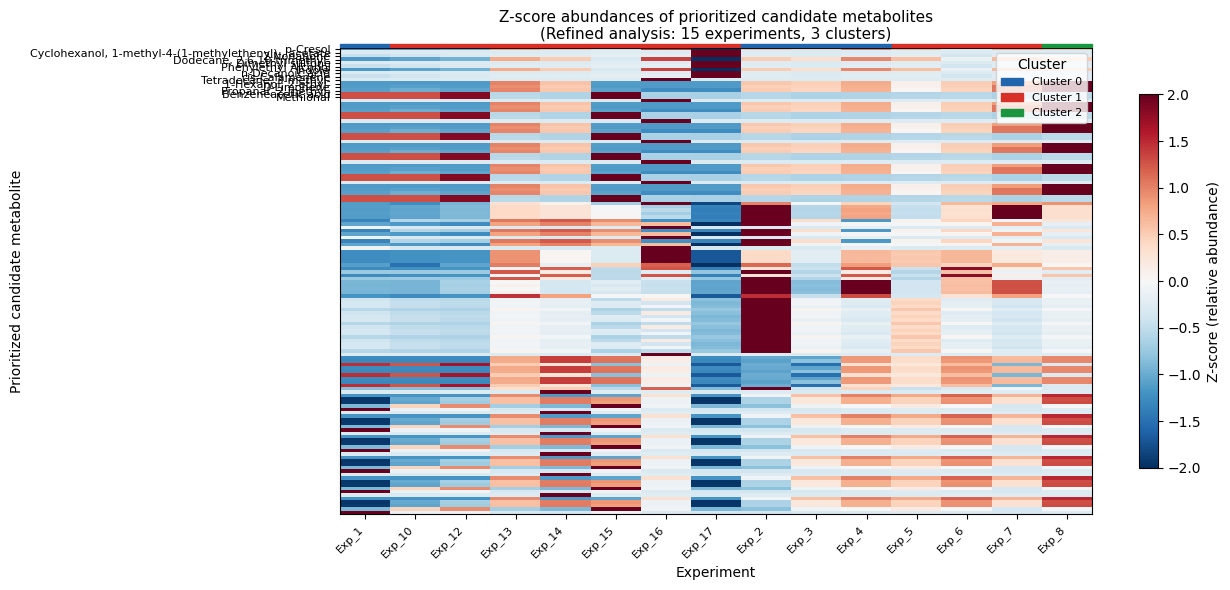

Saved: 08_zscore_heatmap_candidates.png


In [37]:
# ============================================================
# HEATMAP Z-SCORE – abundancias reales de candidatos priorizados
# ============================================================
from scipy.stats import zscore as _zscore

# Candidatos sin contaminantes, top 15
hm_cands_df = prio_final.copy()
hm_cands_df = hm_cands_df[
    ~hm_cands_df['Flag_contaminante'].astype(str).isin(
        ['True','true','1','yes','Posible_contaminante'])
].head(15)
hm_cands = hm_cands_df['metabolite'].tolist()

hm_avail = [m for m in hm_cands if m in X_ml_no.columns]
if not hm_avail:
    hm_avail = [m for m in hm_cands if m in X_ml.columns]
    hm_src   = X_ml[hm_avail].loc[exp_included] if hm_avail else None
else:
    hm_src = X_ml_no[hm_avail]

if hm_src is not None and len(hm_avail) > 0:
    hm_z = hm_src.apply(_zscore, axis=0).fillna(0)

    colores_cluster = {0: '#2166ac', 1: '#d73027', 2: '#1a9641'}
    colores_fila = [colores_cluster.get(int(c), '#aaaaaa') for c in y_no]

    fig, ax = plt.subplots(figsize=(13, 6))
    im = ax.imshow(hm_z.values.T, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)

    ax.set_xticks(range(len(hm_z.index)))
    ax.set_xticklabels(hm_z.index, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(hm_avail)))
    ax.set_yticklabels(hm_avail, fontsize=8)

    # Barra de colores de cluster sobre el eje X
    for xi, col in enumerate(colores_fila):
        ax.add_patch(plt.Rectangle((xi - 0.5, -1.7), 1, 1,
                                   color=col, clip_on=False, zorder=3))

    plt.colorbar(im, ax=ax, label='Z-score (abundancia relativa)', shrink=0.8)

    leyenda_h = [mpatches.Patch(color=c, label=f'Cluster {k}')
                 for k, c in colores_cluster.items() if k in np.unique(y_no)]
    ax.legend(handles=leyenda_h, loc='upper right', fontsize=8, title='Cluster')

    ax.set_xlabel('Experimento', fontsize=10)
    ax.set_ylabel('Metabolito candidato priorizado', fontsize=10)
    ax.set_title(
        'Abundancias Z-score de los metabolitos candidatos priorizados\n'
        '(Análisis refinado: 15 experimentos, 3 clusters)', fontsize=11)

    plt.tight_layout()
    plt.savefig(FIGURES / '08_zscore_heatmap_candidatos.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: 08_zscore_heatmap_candidatos.png')
else:
    print('No se encontraron metabolitos coincidentes en X_ml_no para el heatmap z-score.')


## Bubble Plot: Guía de Interpretación

El bubble plot siguiente permite priorizar visualmente los metabolitos candidatos
usando **tres métricas independientes de forma simultánea**:

| Elemento visual | Eje / propiedad | Qué mide |
|-----------------|-----------------|----------|
| **Eje X** | Importancia SHAP | Importancia predictiva para el modelo (contribución a la separación de clusters) |
| **Eje Y** | \|log2 fold change\| | Tamaño del efecto (magnitud de la diferencia de abundancia entre clusters) |
| **Tamaño de burbuja** | -log10(p_adjusted) | Evidencia estadística (burbuja mayor = más significativo) |
| **Color de burbuja** | Confianza del origen | Verde = alta, naranja = media, rojo = baja, gris = desconocida |

> **Cómo leer el gráfico:** Los metabolitos en la **zona superior derecha** con **burbujas grandes**
> son los candidatos más sólidos: combinan alta importancia predictiva, gran tamaño de efecto
> y fuerte evidencia estadística. Los metabolitos muy a la derecha pero bajos en Y tienen alta
> importancia para el modelo pero moderado fold-change; los que están altos en Y pero a la izquierda
> muestran gran tamaño de efecto con limitada contribución predictiva.


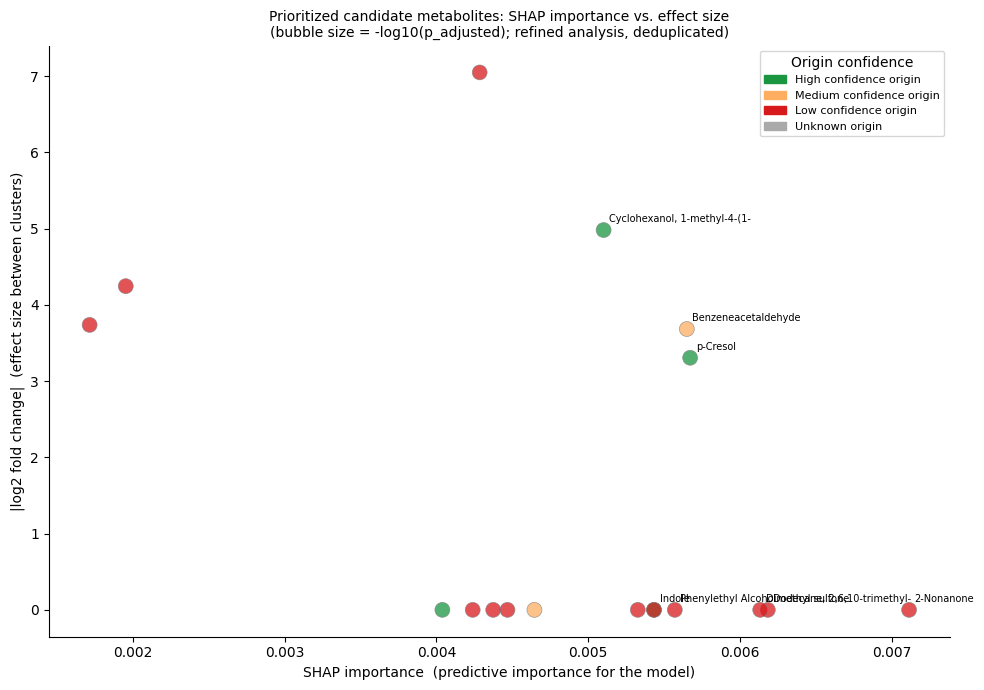

Saved: 08_bubble_candidates_refined.png


In [38]:
# ============================================================
# BUBBLE PLOT – análisis refinado (metabolitos candidatos priorizados)
# ============================================================

plot_b2 = prio_final.head(20).copy()
plot_b2['neg_log10_p']   = -np.log10(np.clip(plot_b2['p_adjusted'].fillna(1).values, 1e-10, 1))
plot_b2['shap_mean_abs'] = plot_b2['shap_mean_abs'].fillna(0)
plot_b2['abs_log2fc']    = plot_b2['abs_log2fc'].fillna(0)

paleta_conf = {'Alta': '#1a9641', 'Media': '#fdae61',
               'Baja': '#d7191c', 'Desconocida': '#aaaaaa'}
colores_pt2 = [paleta_conf.get(str(c), '#aaaaaa') for c in plot_b2['Confianza_origen']]
tamanos2 = np.clip(plot_b2['neg_log10_p'].values * 80, 30, 500)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(plot_b2['shap_mean_abs'], plot_b2['abs_log2fc'],
           s=tamanos2, c=colores_pt2, alpha=0.75, edgecolors='gray', linewidths=0.5)

# Etiquetar solo los top 8 para evitar solapamiento
etiquetas_b2 = []
for _, row in plot_b2.head(8).iterrows():
    t = ax.annotate(str(row['metabolite'])[:28],
                    (row['shap_mean_abs'], row['abs_log2fc']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')
    etiquetas_b2.append(t)

# Separar etiquetas automáticamente si adjustText está disponible
try:
    from adjustText import adjust_text
    adjust_text(etiquetas_b2, ax=ax,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                expand_points=(1.4, 1.4), force_text=(0.5, 0.8))
except ImportError:
    pass  # adjustText no instalado; etiquetas con offset fijo

leyenda_b2 = [
    mpatches.Patch(color='#1a9641', label='Origen de alta confianza'),
    mpatches.Patch(color='#fdae61', label='Origen de media confianza'),
    mpatches.Patch(color='#d7191c', label='Origen de baja confianza'),
    mpatches.Patch(color='#aaaaaa', label='Origen desconocido'),
]
ax.legend(handles=leyenda_b2, title='Confianza del origen', fontsize=8, loc='upper right')

ax.set_xlabel('Importancia SHAP  (importancia predictiva para el modelo)', fontsize=10)
ax.set_ylabel('|log2 fold change|  (tamaño del efecto entre clusters)', fontsize=10)
ax.set_title(
    'Metabolitos candidatos priorizados: importancia SHAP vs. tamaño del efecto\n'
    '(tamaño de burbuja = -log10(p_ajustado); análisis refinado, deduplicado)',
    fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES / '08_bubble_candidatos_refinado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: 08_bubble_candidatos_refinado.png')


## Interpretación Final de los Metabolitos Candidatos

### Consideraciones científicas

Los metabolitos identificados en este notebook **no deben interpretarse como biomarcadores confirmados**.
Representan **metabolitos candidatos priorizados** (también denominados *características de interés*
o *metabolitos priorizados*) identificados mediante la convergencia de tres líneas independientes de evidencia:

1. **Importancia predictiva** (SHAP): estas características contribuyen más a la capacidad del modelo para separar clusters.
2. **Tamaño del efecto** (|log2FC|): estas características muestran las mayores diferencias de fold-change entre clusters.
3. **Evidencia estadística** (p-valor ajustado): estas características muestran diferencias menos probablemente explicadas por azar.

Ningún criterio por sí solo es suficiente para afirmar relevancia biológica.

---

### Comparativa de los dos análisis

| | Análisis original | Análisis refinado |
|---|---|---|
| Experimentos | 17 (todos) | 15 (excl. Exp_9, Exp_11) |
| Clusters | 2 (desbalance extremo de clases) | 3 (más equilibrado) |
| Interpretación | Exploratorio | **Principal** |
| Potencia estadística | Muy baja (clase minoritaria n = 1) | Baja-moderada |
| Fiabilidad SHAP | Inestable (dominado por outlier único) | Más robusta |

> **El análisis refinado es la base recomendada para la interpretación**, ya que evita
> los artefactos estadísticos introducidos por un único outlier extremo y proporciona
> clusters más equilibrados con atribuciones SHAP más interpretables.

---

### Próximos pasos recomendados

- **Validar** los principales metabolitos candidatos mediante métodos dirigidos (p. ej., GC-MS cuantitativo o RMN).
- **Aumentar el tamaño muestral** para mejorar la potencia estadística y reducir la tasa de falsos positivos.
- **Contrastar** los candidatos con bases de datos externas de metabolómica (HMDB, METLIN, MassBank)
  para evaluar su plausibilidad biológica.
- **Considerar variables de confusión** (recogida de muestras, almacenamiento, variación técnica)
  antes de cualquier interpretación biológica.
- Usar el término *metabolitos candidatos* o *características de interés* en lugar de *biomarcadores*
  en todas las comunicaciones hasta obtener una validación independiente.
